# LLM-based program repair on Defects4J: qwen3.6:35b vs gpt-oss:120b

Comparative analysis of two full campaigns over the **854 active Defects4J
bugs**, one `Experiment.py` run per bug and per model, identical configuration
(`--include-test-code --include-test-log --include-issue --fixcheck
--fixcheck-prefixes 10`, temperature 0.0). See the repository `README.md` for
the methodology and `docs/campaign.md` for the campaign protocol.

**How to read the outcome flags.** Each one is a stricter bar than the
last, so every stage is a subset of the previous one:

- `applied` — the generated diff could be applied to the checkout at all;
- `triggers_fixed` — the bug's trigger tests pass after the patch;
- `fixed` — the patched sources compile, `triggers_fixed` holds, and the patch
  introduces no new failing test.

**Caveats stated up front**

- One run per bug: every rate below is a *single sample* of a non-deterministic
  process. Differences of a few bugs are noise; no significance claims are made.
- The two models ran on different GPUs (qwen3.6:35b on L40S, gpt-oss:120b on
  H100), so wall-clock seconds are not hardware-comparable — token counts are.
- FixCheck verdicts are advisory single samples; a `suspicious: false` is weak
  evidence (see `docs/fixcheck-verdict-limitations.md`), and some verdicts are
  *vacuous* (nothing was analyzed). Section 6 separates those.


## 1. Setup and data loading

One tidy DataFrame, one row per `(model, project, bug_id)`. The loader is
`summarize_campaign.collect_project()` — the same code the CLI aggregator uses,
so the notebook and `summarize_campaign.py` cannot disagree about the schema.


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

# Repo root = nearest ancestor holding results/ (works from analysis/ and from
# a headless nbconvert run alike).
REPO = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "results").is_dir())
sys.path.insert(0, str(REPO))

from d4j.defects4j_bugs import PROJECT_BUG_COUNTS, TOTAL_ACTIVE_BUGS
from summarize_campaign import collect_project

MODELS = ["qwen3.6:35b", "gpt-oss:120b"]
# Color follows the entity in every figure (categorical slots 1 and 2 of the
# validated palette; CVD-safe pair).
MODEL_COLORS = {"qwen3.6:35b": "#2a78d6", "gpt-oss:120b": "#eb6834"}

rows = []
for model in MODELS:
    root = REPO / "results" / model
    for project in PROJECT_BUG_COUNTS:
        for record in collect_project(str(root), project):
            rows.append({"model": model, **record})
df = pd.DataFrame(rows)
df["bug"] = df["project"] + "-" + df["bug_id"]

print(f"{len(df)} rows ({TOTAL_ACTIVE_BUGS} active bugs x {len(MODELS)} models = "
      f"{TOTAL_ACTIVE_BUGS * len(MODELS)} possible)")
df.head(3)


1708 rows (854 active bugs x 2 models = 1708 possible)


,model,project,bug_id,status,exit_code,seconds,has_result,applied,compiled_after,triggers_fixed,...,fixcheck_analyzed,failing_prefixes,max_failure_similarity,fixcheck_suspicious,included_issue,issue_status,llm_seconds,input_tokens,output_tokens,bug
0,qwen3.6:35b,Chart,1,ok,0,221.7,True,True,True,True,...,1,0,0.000000,False,False,unusable,34.552,19059.0,1559.0,Chart-1
1,qwen3.6:35b,Chart,10,ok,0,120.9,True,True,True,True,...,0,0,0.000000,False,False,empty,88.620,2052.0,4079.0,Chart-10
2,qwen3.6:35b,Chart,11,ok,0,542.2,True,True,True,True,...,1,7,0.539095,False,False,unusable,51.502,7914.0,2462.0,Chart-11


In [2]:
# Recessive, consistent chart defaults: y-grid only, no chart junk.
plt.rcParams.update({
    "figure.figsize": (9, 4.5), "figure.dpi": 110,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "axes.axisbelow": True,
    "grid.color": "#e6e4dd", "grid.linewidth": 0.8,
    "axes.grid.axis": "y",
    "font.size": 10,
})


## 2. Data quality and completeness

Not every bug produced a `result.json`: a run can error (checkout/compile
failures are expected for some Defects4J bugs under this image) or time out,
and a handful were never attempted. These rows are *reported*, then excluded
from the comparison — hiding them would inflate the denominators.


In [3]:
completeness = (
    df.assign(completed=df["has_result"])
      .groupby("model")
      .agg(attempted=("bug", "count"),
           completed=("completed", "sum"),
           errored=("status", lambda s: (s == "error").sum()),
           timed_out=("status", lambda s: (s == "timeout").sum()))
)
completeness["never_attempted"] = TOTAL_ACTIVE_BUGS - completeness["attempted"]
completeness


,attempted,completed,errored,timed_out,never_attempted
model,,,,,
gpt-oss:120b,854,848,2,4,0
qwen3.6:35b,854,852,0,2,0


In [4]:
# Which projects are missing bugs, per model (completed vs the project's total)?
per_project = (
    df[df["has_result"]]
    .groupby(["model", "project"])["bug"].count().unstack(0)
    .reindex(PROJECT_BUG_COUNTS).fillna(0).astype(int)
)
per_project["active_bugs"] = pd.Series(PROJECT_BUG_COUNTS)
incomplete = per_project[(per_project[MODELS].lt(per_project["active_bugs"], axis=0)).any(axis=1)]
incomplete


model,gpt-oss:120b,qwen3.6:35b,active_bugs
project,,,
Chart,24,26,26
Compress,46,47,47
JacksonXml,5,5,6
Math,104,105,106


**Prompt-leakage guard.** Issue reports are cut at the first `Comment:` line
before reaching the prompt (`strip_issue_comments`), because the maintainers'
thread routinely discusses the fix. This cell re-verifies that **no prompt in
either tree** contains the thread, so the guarantee survives any future
regeneration of the data.


In [5]:
import re

comment_marker = re.compile(r"^Comment:\s*$", re.M)
leaked = []
for model in MODELS:
    for prompt_path in (REPO / "results" / model).glob("*/Bug_*/prompt.txt"):
        text = prompt_path.read_text(encoding="utf-8", errors="replace")
        start = text.find("[ORIGINAL ISSUE REPORT]")
        if start == -1:
            continue
        end = text.find("\n[", start + 5)
        if comment_marker.search(text[start:end if end != -1 else None]):
            leaked.append(prompt_path)
assert not leaked, f"{len(leaked)} prompts contain the issue comment thread: {leaked[:5]}"
print("OK: no prompt carries the issue comment thread.")


OK: no prompt carries the issue comment thread.


### 2.1 Patches that applied but did not compile

Applying cleanly and compiling are different bars, and a sizeable slice of the
generated patches clears the first but not the second: `git apply` only needs
the context lines to match, while `javac` needs the result to be valid Java.
These runs count as attempted and completed, never as fixed.


In [6]:
completed_runs = df[df["has_result"]].assign(
    applied_but_not_compiled=lambda t: t["applied"] & ~t["compiled_after"]
)
compile_stats = (
    completed_runs
    .groupby("model")
    .agg(applied=("applied", "sum"),
         did_not_compile=("applied_but_not_compiled", "sum"))
    .reindex(MODELS)
)
compile_stats["% of applied"] = (
    compile_stats["did_not_compile"] / compile_stats["applied"] * 100
).round(1)
compile_stats


,applied,did_not_compile,% of applied
model,,,
qwen3.6:35b,771,104,13.5
gpt-oss:120b,775,99,12.8


They concentrate in the largest, most complex projects, where a patch has more
surrounding API to get wrong:


In [7]:
not_compiled = df[df["has_result"] & df["applied"] & ~df["compiled_after"]]
(not_compiled.groupby(["project", "model"])["bug"].count()
 .unstack("model").reindex(columns=MODELS).fillna(0).astype(int)
 .assign(total=lambda t: t.sum(axis=1)).sort_values("total", ascending=False).head(8))


model,qwen3.6:35b,gpt-oss:120b,total
project,,,
Closure,34,31,65
JacksonDatabind,26,19,45
Jsoup,6,12,18
Math,7,8,15
Mockito,7,4,11
Collections,4,5,9
JxPath,2,5,7
Cli,5,1,6


## 3. Paired dataset

The model comparison uses only bugs with a completed run in **both** trees:
same denominator, fair bug-for-bug comparison, and it enables the agreement
matrix of section 4. Everything excluded here was already accounted for in
section 2.


In [8]:
completed = df[df["has_result"]]
counts = completed.groupby("bug")["model"].nunique()
paired_bugs = set(counts[counts == len(MODELS)].index)
paired = completed[completed["bug"].isin(paired_bugs)].copy()

for model in MODELS:
    lost = completed[completed["model"] == model]["bug"].nunique() - len(paired_bugs)
    print(f"{model}: {lost} completed bug(s) dropped by pairing")
print(f"paired comparison set: {len(paired_bugs)} bugs")


qwen3.6:35b: 5 completed bug(s) dropped by pairing
gpt-oss:120b: 1 completed bug(s) dropped by pairing
paired comparison set: 847 bugs


## 4. Core comparison

### 4.1 Patch outcomes, stage by stage

How far does each model get, over the same paired bugs? Each stage is a subset
of the previous one.


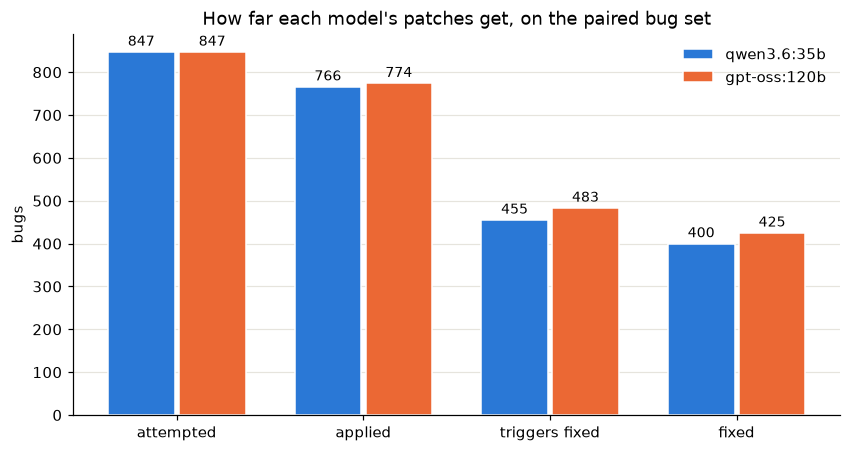

,applied %,triggers_fixed %,fixed %
model,,,
qwen3.6:35b,90.4,53.7,47.2
gpt-oss:120b,91.4,57.0,50.2


In [9]:
stages = ["applied", "triggers_fixed", "fixed"]
stage_counts = paired.groupby("model")[stages].sum().reindex(MODELS)
stage_counts.insert(0, "attempted", len(paired_bugs))

fig, ax = plt.subplots()
x = range(len(stage_counts.columns))
width = 0.38
for i, model in enumerate(MODELS):
    values = stage_counts.loc[model]
    bars = ax.bar([p + (i - 0.5) * width for p in x], values, width * 0.94,
                  color=MODEL_COLORS[model], label=model, edgecolor="white")
    ax.bar_label(bars, fmt="%d", padding=2, fontsize=9)
ax.set_xticks(list(x), ["attempted", "applied", "triggers fixed", "fixed"])
ax.set_ylabel("bugs")
ax.set_title("How far each model's patches get, on the paired bug set")
ax.legend(frameon=False)
plt.show()

stage_rates = (stage_counts[stages].div(len(paired_bugs)) * 100).round(1)
stage_rates.columns = [c + " %" for c in stages]
stage_rates


The `triggers_fixed` → `fixed` drop is patches that satisfy the trigger tests
but **break something else** (`new_failures`); the count per model:


In [10]:
regressions = paired[paired["triggers_fixed"] & ~paired["fixed"]]
regressions.groupby("model")["bug"].count().rename("plausible but regressing").to_frame()


,plausible but regressing
model,
gpt-oss:120b,58
qwen3.6:35b,55


### 4.2 Fixed rate per project

Same paired set, split by project. Project size varies wildly (JacksonXml has
6 bugs, Closure 174), so the *rate* is plotted and the project's paired size is
in the axis label.


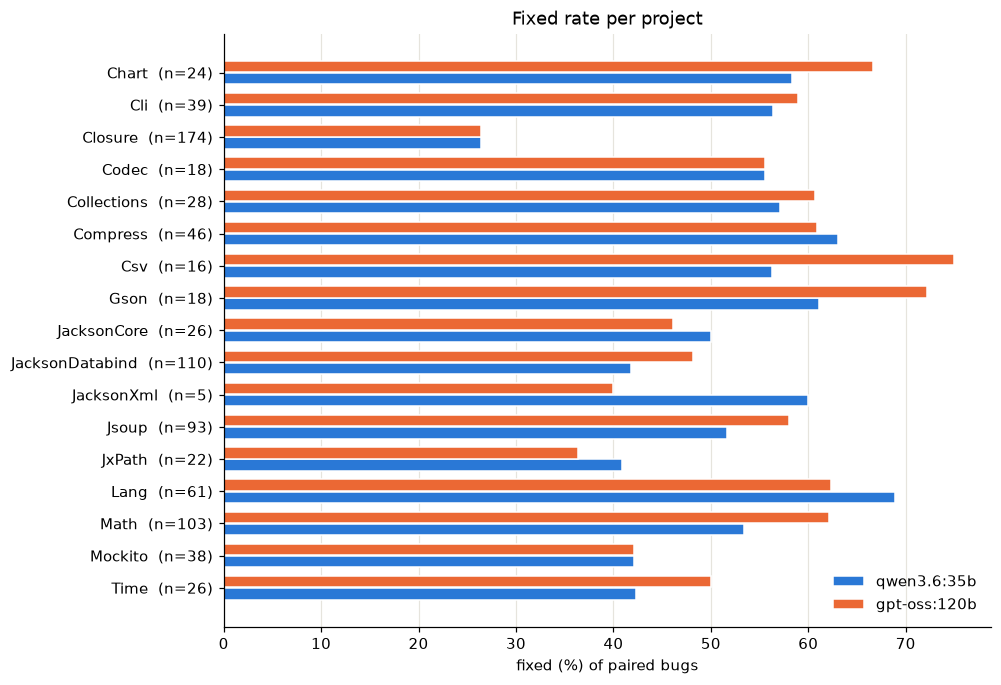

In [11]:
by_project = (
    paired.groupby(["project", "model"])["fixed"].agg(["sum", "count"]).reset_index()
)
by_project["rate"] = by_project["sum"] / by_project["count"] * 100
rate = by_project.pivot(index="project", columns="model", values="rate").reindex(PROJECT_BUG_COUNTS)
sizes = by_project.pivot(index="project", columns="model", values="count").reindex(PROJECT_BUG_COUNTS)

fig, ax = plt.subplots(figsize=(9, 7))
ax.grid(axis="x"); ax.grid(axis="y", visible=False)
y = range(len(rate))
height = 0.38
for i, model in enumerate(MODELS):
    ax.barh([p + (0.5 - i) * height for p in y], rate[model], height * 0.94,
            color=MODEL_COLORS[model], label=model, edgecolor="white")
ax.set_yticks(list(y), [f"{p}  (n={int(sizes.loc[p].iloc[0])})" for p in rate.index])
ax.invert_yaxis()
ax.set_xlabel("fixed (%) of paired bugs")
ax.set_title("Fixed rate per project")
ax.legend(frameon=False, loc="lower right")
plt.show()


### 4.3 Agreement matrix

Where do the models agree, and which bugs does exactly one of them fix? The
"only one" cells are the natural candidates for later qualitative deep-dives.


In [12]:
wide = paired.pivot(index="bug", columns="model", values="fixed")
q, g = MODELS
matrix = pd.DataFrame(
    [[int((wide[q] & wide[g]).sum()), int((wide[q] & ~wide[g]).sum())],
     [int((~wide[q] & wide[g]).sum()), int((~wide[q] & ~wide[g]).sum())]],
    index=pd.Index([f"{q}: fixed", f"{q}: not fixed"]),
    columns=pd.Index([f"{g}: fixed", f"{g}: not fixed"]),
)
matrix


,gpt-oss:120b: fixed,gpt-oss:120b: not fixed
qwen3.6:35b: fixed,310,90
qwen3.6:35b: not fixed,115,332


In [13]:
only_q = sorted(wide[wide[q] & ~wide[g]].index)
only_g = sorted(wide[~wide[q] & wide[g]].index)
print(f"fixed ONLY by {q} ({len(only_q)}):\n  " + ", ".join(only_q) + "\n")
print(f"fixed ONLY by {g} ({len(only_g)}):\n  " + ", ".join(only_g))


fixed ONLY by qwen3.6:35b (90):
  Chart-3, Cli-31, Cli-37, Cli-38, Cli-9, Closure-1, Closure-107, Closure-114, Closure-130, Closure-150, Closure-152, Closure-160, Closure-17, Closure-18, Closure-20, Closure-23, Closure-26, Closure-52, Closure-56, Closure-68, Closure-75, Closure-80, Codec-18, Codec-3, Collections-19, Collections-21, Collections-23, Collections-6, Compress-10, Compress-13, Compress-24, Compress-32, Compress-43, Csv-15, Gson-3, JacksonCore-11, JacksonCore-21, JacksonCore-7, JacksonDatabind-110, JacksonDatabind-26, JacksonDatabind-29, JacksonDatabind-32, JacksonDatabind-44, JacksonDatabind-47, JacksonDatabind-5, JacksonDatabind-51, JacksonDatabind-53, JacksonDatabind-54, JacksonDatabind-58, JacksonDatabind-82, JacksonXml-3, Jsoup-28, Jsoup-29, Jsoup-32, Jsoup-48, Jsoup-49, Jsoup-50, Jsoup-52, Jsoup-53, Jsoup-55, Jsoup-60, Jsoup-69, Jsoup-74, JxPath-15, JxPath-19, Lang-1, Lang-22, Lang-24, Lang-32, Lang-35, Lang-4, Lang-41, Lang-43, Lang-46, Lang-58, Math-101, Math-25, Math

## 5. Cost: tokens and time

Two clocks exist and must not be conflated: `llm_seconds` is fix *generation*
only, while `seconds` is the whole run's wall clock (checkout, compile, test
suite, FixCheck). And since the models ran on different GPU types, **tokens are
the only hardware-neutral cost unit** — seconds are shown for operational
interest only.


In [14]:
cost = paired.dropna(subset=["output_tokens"])
summary_cost = cost.groupby("model").agg(
    median_input_tokens=("input_tokens", "median"),
    median_output_tokens=("output_tokens", "median"),
    median_llm_seconds=("llm_seconds", "median"),
    median_wall_seconds=("seconds", "median"),
).round(1).reindex(MODELS)
summary_cost


,median_input_tokens,median_output_tokens,median_llm_seconds,median_wall_seconds
model,,,,
qwen3.6:35b,8882.0,5829.0,61.6,156.7
gpt-oss:120b,8057.0,1694.0,25.2,116.8


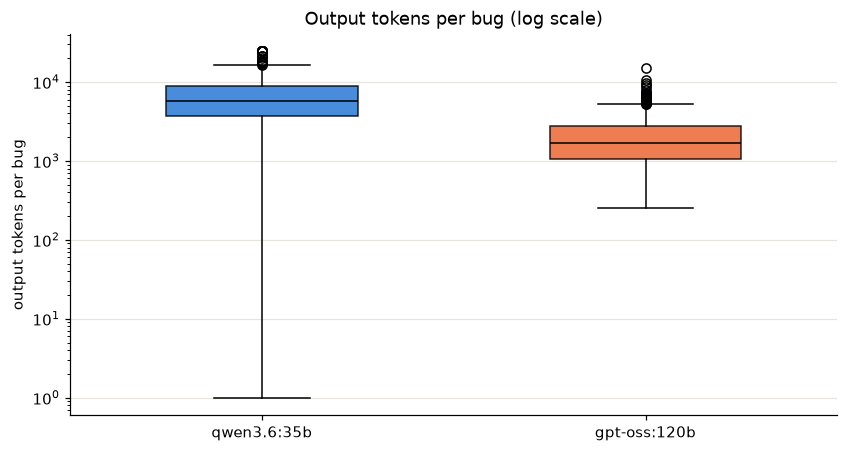

In [15]:
fig, ax = plt.subplots()
data = [cost.loc[cost["model"] == m, "output_tokens"] for m in MODELS]
parts = ax.boxplot(data, tick_labels=MODELS, patch_artist=True, widths=0.5,
                   medianprops={"color": "black"})
for patch, model in zip(parts["boxes"], MODELS):
    patch.set_facecolor(MODEL_COLORS[model]); patch.set_alpha(0.85)
ax.set_ylabel("output tokens per bug")
ax.set_yscale("log")
ax.set_title("Output tokens per bug (log scale)")
plt.show()


**Cost per success** — median output tokens spent per bug, next to each
model's fixed count, gives a rough fixes-per-token economy:


In [16]:
per_success = paired.groupby("model").agg(
    fixed=("fixed", "sum"),
    total_output_tokens=("output_tokens", "sum"),
).reindex(MODELS)
per_success["output_tokens_per_fix"] = (
    per_success["total_output_tokens"] / per_success["fixed"]
).round(0)
per_success


,fixed,total_output_tokens,output_tokens_per_fix
model,,,
qwen3.6:35b,400,6010337.0,15026.0
gpt-oss:120b,425,1831185.0,4309.0


## 6. FixCheck overfitting check

FixCheck runs only on *plausible* patches (applied + trigger tests passing) and
its verdict never changes `fixed` — it is advisory. Two things matter when
reading it:

- a verdict with `fixcheck_analyzed == 0` is **vacuous**: no trigger class
  could be mutated, so "not suspicious" carries no information;
- even a real `suspicious: false` is weak evidence — single sample, known
  detection limits (`docs/fixcheck-verdict-limitations.md`).


In [17]:
plausible = paired[paired["triggers_fixed"]]
fixcheck = plausible.groupby("model").agg(
    plausible_patches=("bug", "count"),
    fixcheck_ran=("fixcheck_ran", "sum"),
    real_verdicts=("fixcheck_analyzed", lambda s: (s > 0).sum()),
    vacuous_verdicts=("fixcheck_analyzed", lambda s: (s == 0).sum()),
    suspicious=("fixcheck_suspicious", "sum"),
).reindex(MODELS)
fixcheck


,plausible_patches,fixcheck_ran,real_verdicts,vacuous_verdicts,suspicious
model,,,,,
qwen3.6:35b,455,455,337,118,1
gpt-oss:120b,483,483,366,117,1


In [18]:
suspicious_bugs = paired[paired["fixcheck_suspicious"]]
suspicious_bugs[["model", "bug", "fixed", "fixcheck_analyzed"]]


,model,bug,fixed,fixcheck_analyzed
725,qwen3.6:35b,Math-40,False,1
908,gpt-oss:120b,Cli-35,True,1


### 6.1 Why so many verdicts are vacuous

A vacuous verdict (`fixcheck_analyzed == 0`) is not always a legitimate skip.
It splits into two very different things, and only the first is by design:

- **skips** — the trigger method has no literal to mutate outside its
  assertions, or it is inherited so FixCheck cannot see its source;
- **crashes** — FixCheck died without writing `report.csv`. Two known upstream
  failure modes dominate: a `NullPointerException` in
  `generateSimilarPrefixes` when a generated prefix fails to compile (the
  execution result is `null` and gets dereferenced), and
  `IllegalArgumentException: No locals of type <T>` when our `inputs-class`
  heuristic picks a type FixCheck then cannot find in some method.

The counts below are read from the run's own `fixcheck.log`, so they reflect
what actually happened rather than what the record says.


In [19]:
import glob as _glob
import json
from collections import Counter

def vacuous_reason(model, project, bug_id, per_class):
    """Why a run produced no evidence: a legitimate skip, or a crash."""
    errors = [r.get("error") or "" for r in per_class]
    if any("report.csv missing" in e for e in errors):
        logs = _glob.glob(
            f"{REPO}/results/{model}/{project}/Bug_{bug_id}/fixcheck/*/fixcheck.log")
        text = "".join(open(p, encoding="utf-8", errors="replace").read() for p in logs)
        if "No locals of type" in text:
            return "crash: inputs-class heuristic mismatch"
        if "NullPointerException" in text:
            return "crash: a prefix did not compile (upstream NPE)"
        return "crash: other"
    if any("no mutable literal" in e for e in errors):
        return "skip: no mutable literal outside assertions"
    if any("not declared in this class" in e for e in errors):
        return "skip: inherited trigger method"
    return "skip: other"

reasons = Counter()
for model in MODELS:
    for path in _glob.glob(f"{REPO}/results/{model}/*/Bug_*/result.json"):
        record = json.loads(open(path).read())
        block = record.get("fixcheck") or {}
        if not record.get("triggers_fixed") or block.get("analyzed_test_classes", 0):
            continue
        project, bug_id = path.split("/")[-3], path.split("/")[-2][4:]
        reasons[vacuous_reason(model, project, bug_id, block.get("per_test_class", []))] += 1

vacuous = pd.Series(reasons).sort_values(ascending=False).rename("runs").to_frame()
vacuous["share %"] = (vacuous["runs"] / vacuous["runs"].sum() * 100).round(1)
vacuous


,runs,share %
skip: no mutable literal outside assertions,79,33.6
crash: inputs-class heuristic mismatch,56,23.8
crash: a prefix did not compile (upstream NPE),55,23.4
crash: other,30,12.8
skip: inherited trigger method,15,6.4


### 6.2 Why so few patches are flagged

The verdict is **not** "nothing failed". Most analysed runs *do* have a failing
variation — what filters them out is the similarity score, and almost the whole
distribution sits far below the 0.8 threshold. The two flagged patches are the
tail of a continuous distribution, not a separated cluster.


In [20]:
analysed = paired[paired["fixcheck_analyzed"] > 0].copy()
with_failures = analysed[analysed["failing_prefixes"] > 0]
print(f"analysed runs:                {len(analysed)}")
print(f"  with >=1 failing variation: {len(with_failures)} "
      f"({100 * len(with_failures) / len(analysed):.0f}%)")
print(f"  flagged suspicious:         {int(analysed['fixcheck_suspicious'].sum())}")


analysed runs:                703
  with >=1 failing variation: 589 (84%)
  flagged suspicious:         2


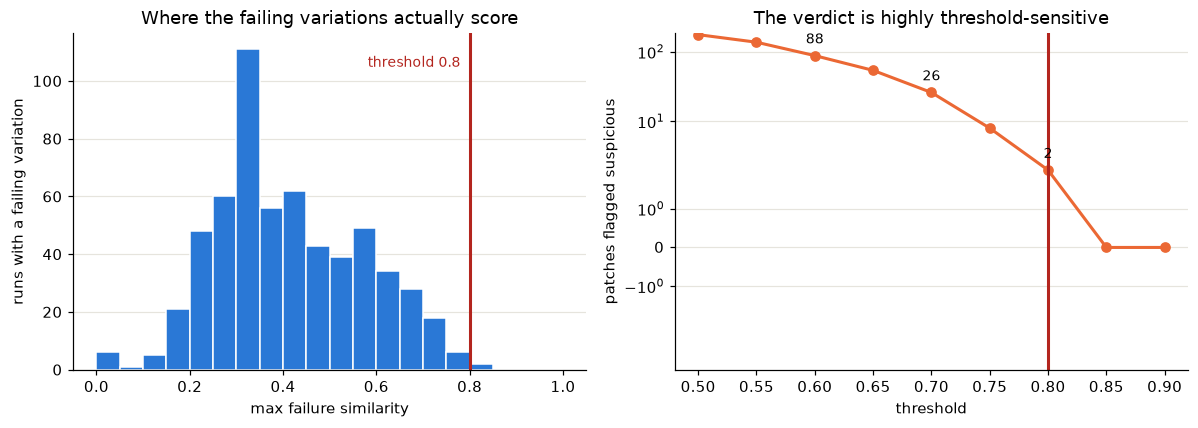

threshold,0.50,0.55,0.60,0.65,0.70,0.75,0.80,0.85,0.90
flagged,176,137,88,54,26,8,2,0,0


In [21]:
scores = with_failures["max_failure_similarity"]
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

ax1.hist(scores, bins=20, range=(0, 1), color=MODEL_COLORS[MODELS[0]], edgecolor="white")
ax1.axvline(0.8, color="#b3251e", linewidth=2)
ax1.annotate("threshold 0.8", xy=(0.8, ax1.get_ylim()[1] * 0.9), xytext=(-6, 0),
             textcoords="offset points", ha="right", color="#b3251e", fontsize=9)
ax1.set_xlabel("max failure similarity")
ax1.set_ylabel("runs with a failing variation")
ax1.set_title("Where the failing variations actually score")

thresholds = [round(t, 2) for t in [0.5, 0.55, 0.6, 0.65, 0.7, 0.75, 0.8, 0.85, 0.9]]
flagged = [int((scores >= t).sum()) for t in thresholds]
ax2.plot(thresholds, flagged, marker="o", color=MODEL_COLORS[MODELS[1]], linewidth=2)
ax2.axvline(0.8, color="#b3251e", linewidth=2)
ax2.set_xlabel("threshold")
ax2.set_ylabel("patches flagged suspicious")
ax2.set_title("The verdict is highly threshold-sensitive")
ax2.set_yscale("symlog")
for t, n in zip(thresholds, flagged):
    if t in (0.6, 0.7, 0.8):
        ax2.annotate(f"{n}", xy=(t, n), xytext=(0, 8), textcoords="offset points",
                     ha="center", fontsize=9)
plt.tight_layout()
plt.show()

pd.DataFrame({"threshold": thresholds, "flagged": flagged}).set_index("threshold").T


### 6.3 What the two flagged patches actually show

Both were inspected by hand against their `fixcheck.log`, and **both are false
positives** — for different reasons:

**Math 40** (qwen3.6:35b, similarity 0.848). FixCheck mutated the literal `100`
into `49`. That `100` is the solver's *maximum evaluation count*, so the
variation naturally throws the same `TooManyEvaluationsException` with an almost
identical trace. This is the role-blind mutation limitation in its purest form:
the mutated value is a configuration parameter, not test data. The patch was
already known bad anyway (`fixed=False` — it broke three other tests), so the
flag added nothing.

**Cli 35** (gpt-oss:120b, similarity 0.812), the one that had passed every other
check. Bug CLI-252 is that `--prefix` was reported ambiguous despite exactly
matching the option `prefix`. FixCheck mutated `"--prefix"` into `"--pref"`, and
the variation threw:

```
AmbiguousOptionException: Ambiguous option: '--pref'
                          (could be: 'prefix', 'prefixplusplus')
```

But `--pref` **is** genuinely ambiguous — a prefix of both options and an exact
match for neither — so that exception is *correct* behaviour. The mutation
changed the input from "exact match, must succeed" to "real ambiguity, must
fail" and then read the resulting failure as evidence of overfitting.

Note both have `assertion_failing == 0`: every "failure" is a crash, which is
exactly what role-blind mutation produces.

**Bottom line for reporting.** Across 1144 plausible patches FixCheck surfaced
no real overfitting and two false positives. `fixcheck_suspicious` must not be
presented as an overfitting *rate*; on this configuration the check has no
measurable detection power. See
[docs/fixcheck-verdict-limitations.md](../docs/fixcheck-verdict-limitations.md).


## 7. Does having the issue report help?

Fixed rate split by `issue_status`: `available` means the reporter's original
text was in the prompt; `unusable`/`empty` mean the prompt carried no issue
(SourceForge scrapes to a navigation menu; some bugs have no tracker URL).

**This is not causal.** Chart contributes *zero* issues (all 26 bugs), so
project difficulty and issue availability are confounded — read this as
descriptive only.


In [22]:
issue_effect = (
    paired.assign(has_issue=paired["issue_status"].eq("available"))
    .groupby(["model", "has_issue"])["fixed"].agg(["mean", "count"])
)
issue_effect["mean"] = (issue_effect["mean"] * 100).round(1)
issue_effect.rename(columns={"mean": "fixed %", "count": "bugs"})


fixed %  bugs
model        has_issue               
gpt-oss:120b False         59.0    39
             True          49.8   808
qwen3.6:35b  False         51.3    39
             True          47.0   808

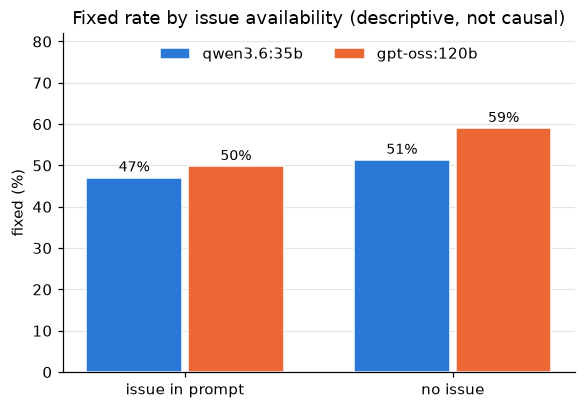

In [23]:
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["issue in prompt", "no issue"]
x = range(len(labels))
width = 0.38
for i, model in enumerate(MODELS):
    sub = paired[paired["model"] == model]
    vals = [
        sub[sub["issue_status"] == "available"]["fixed"].mean() * 100,
        sub[sub["issue_status"] != "available"]["fixed"].mean() * 100,
    ]
    bars = ax.bar([p + (i - 0.5) * width for p in x], vals, width * 0.94,
                  color=MODEL_COLORS[model], label=model, edgecolor="white")
    ax.bar_label(bars, fmt="%.0f%%", padding=2, fontsize=9)
ax.set_xticks(list(x), labels)
ax.set_ylabel("fixed (%)")
ax.set_ylim(0, 82)     # headroom so the legend never collides with bar labels
ax.set_title("Fixed rate by issue availability (descriptive, not causal)")
ax.legend(frameon=False, loc="upper center", ncols=2)
plt.show()


## 8. Headline summary

The numbers a write-up would quote, in one table.


In [24]:
headline = pd.DataFrame({
    model: {
        "completed runs": int(completeness.loc[model, "completed"]),
        "paired bugs": len(paired_bugs),
        "applied": int(stage_counts.loc[model, "applied"]),
        "triggers fixed": int(stage_counts.loc[model, "triggers_fixed"]),
        "fixed": int(stage_counts.loc[model, "fixed"]),
        "fixed % (paired)": round(stage_counts.loc[model, "fixed"] / len(paired_bugs) * 100, 1),
        "plausible but regressing": int(
            regressions.groupby("model")["bug"].count().get(model, 0)),
        "fixcheck suspicious": int(fixcheck.loc[model, "suspicious"]),
        "median output tokens": summary_cost.loc[model, "median_output_tokens"],
    }
    for model in MODELS
})
headline


,qwen3.6:35b,gpt-oss:120b
completed runs,852.0,848.0
paired bugs,847.0,847.0
applied,766.0,774.0
triggers fixed,455.0,483.0
fixed,400.0,425.0
fixed % (paired),47.2,50.2
plausible but regressing,55.0,58.0
fixcheck suspicious,1.0,1.0
median output tokens,5829.0,1694.0


---
*Extension points:* per-bug qualitative review of the "only one model" lists
(section 4.3), repeated runs to move beyond single samples, diff-size analysis
from `fix.diff`, and FixCheck verdict deep-dives via the artifacts under
`results/<model>/<project>/Bug_<id>/fixcheck/`.
